In [1]:
from pathlib import Path
import numpy as np

R  = Path("/grid/koo/home/pmantill/projects/SEAM_validate")
AA = R / "attribution_align"
STEM = "peak84030"          # single sequence to inspect

# four per-sequence wt_attribution maps, aligned to the 200bp variable core (ACGT),
# all mean-centered across channels.
# AGFT maps are already 200bp; LegNet maps are 230bp with the 15bp adapters held
# fixed during mutagenesis -> crop [15:215] to the core.
# LegNet DeepSHAP uses the corefix run (adapters fixed in the dinuc-shuffle
# references + mean-centered); the old legnet_agftlib_deepshap_maps shuffled the
# full 230bp and was not centered.
agft_ism        = np.load(R / "results/single_seq/foregrounds"               / STEM / "wt_attribution.npy")
agft_deepshap   = np.load(R / "results/single_seq/foregrounds_deepshap_lnfix" / STEM / "wt_attribution.npy")
legnet_ism      = np.load(AA / "legnet_agftlib_ism_maps"              / STEM / "wt_attribution.npy")[15:215]
legnet_deepshap = np.load(AA / "legnet_agftlib_deepshap_maps_corefix" / STEM / "wt_attribution.npy")[15:215]

maps = [("AGFT ISM", agft_ism), ("AGFT DeepSHAP", agft_deepshap),
        ("LegNet ISM", legnet_ism), ("LegNet DeepSHAP", legnet_deepshap)]
for name, m in maps:
    print(f"{name:16s} {m.shape}")

AGFT ISM         (200, 4)
AGFT DeepSHAP    (200, 4)
LegNet ISM       (200, 4)
LegNet DeepSHAP  (200, 4)


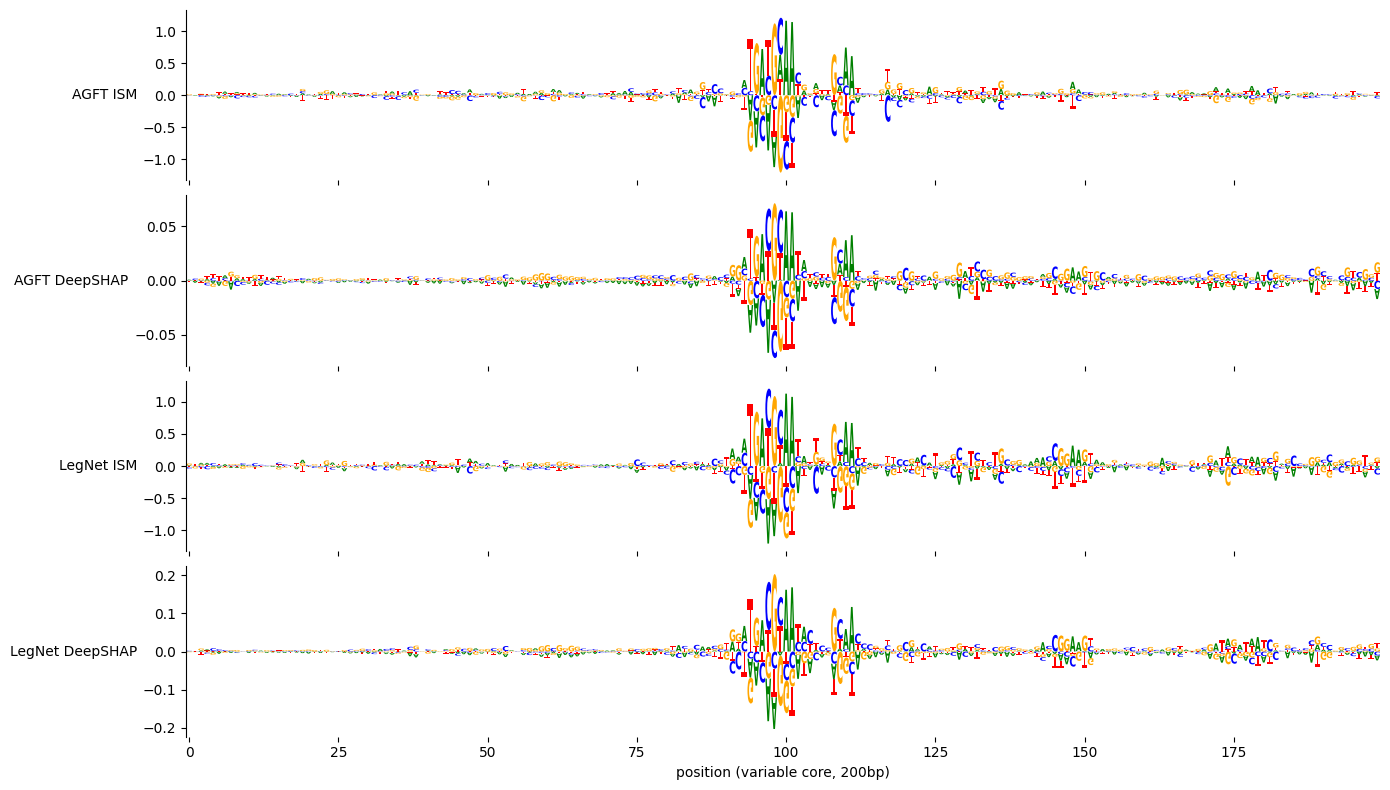

In [2]:
import sys
import matplotlib.pyplot as plt
sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

# stacked attribution logos: the four maps, one per row
fig, axes = plt.subplots(len(maps), 1, figsize=(14, 8), sharex=True)
for ax, (name, m) in zip(axes, maps):
    fast_logo(m, ax)                          # full (L,4) ACGT, all channels
    ax.set_ylabel(name, rotation=0, ha="right", va="center")
    ax.spines[["top", "right", "bottom"]].set_visible(False)
axes[-1].set_xlabel("position (variable core, 200bp)")
fig.tight_layout()
fig.savefig(f"{STEM}_stacked_attmaps.png", dpi=300, bbox_inches="tight")